In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from pathlib import Path
import json
from cfm_mppi.models.transformer import TransformerModel
import torch
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pickle
import time

import matplotlib.pyplot as plt
import matplotlib.animation as animation

from IPython.display import HTML

from cfm_mppi.utils import AgentHistory, evaluate
from cfm_mppi.mppi.flowmppi_candidates import FlowMPPI
from cfm_mppi.mppi.utils import stage_cost, terminal_cost, unicycle_dynamics
from tqdm.notebook import tqdm

# PyTorch and NumPy random seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Matplotlib styling
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams["font.size"] = 15
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

from cfm_mppi.evaluation.eval_utils import CFMConfig, run_CFM


In [11]:
dataset_name = 'ucy'
# --- Model and Data Loading ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Substitute your pretrained checkpoint path
checkpoint_path = Path("../../output_dir/cfm_transformer/checkpoint.pth")
args_filepath = checkpoint_path.parent / 'args.json'
with open(args_filepath, 'r') as f:
    args_dict = json.load(f)

model = TransformerModel()
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model"])
model.to(device=device)
model.train(False)

# --- Dataset Loading ---
batch_ego = torch.load(f'../../dataset/eval80_ego_{dataset_name}.pt', map_location=device)
with open(f'../../dataset/eval80_obs_{dataset_name}.pkl', 'rb') as f:
    batch_obs = pickle.load(f)


In [12]:
# --- General Simulation Parameters ---
SCENARIO_IDX = 110
HORIZON = 80
DT = 0.1
SCALE = 10.0
OBSTACLE_RADIUS = 0.5
EGO_RADIUS = 0.5
COLL_RADIUS = 0.5

# --- CFM-MPPI Parameters ---
SAFE_COEF = [0.1, 0.3, 0.5, 0.7, 0.9]
GOAL_COEF = 0.1

ODE_TIMES = [0.5, 0.8, 0.85, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0]
ODE_TIMES2 = [0.85, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0]
NOISE_LEVEL = torch.tensor([0.8]).cuda()

N_SAMPLES = 200
MAX_HISTORY_LEN = 10

# --- MPPI Controller Settings ---
MPPI_SIGMA = torch.tensor([0.3, 0.6]) # torch.tensor([1.0, 1.0])
MPPI_LAMBDA = 0.1
U_MIN = torch.tensor([-2.0, -2.0])  # Minimum control inputs
U_MAX = torch.tensor([2.0, 2.0])  # Maximum control inputs
D=0.1  # look-ahead distance for unicycle (unused for DI)
DI_KP = 3  # feedback gain for double integrator SI-to-DI conversion


In [13]:
def synthesize_control(
    state, goal_pos, noisy_action_seq, noise_level, obs_positions, obs_velocities, planning_horizon,
    config: CFMConfig, mppi_solver, histories: dict = None, d=0.1, k_p=2.0
):
    if histories is None:
        histories = {}
        
    state_hist = histories.get('ego_state')
    control_hist_sin = histories.get('ego_control_sin')
    obs_state_hist = histories.get('obs_state')
    obs_control_hist = histories.get('obs_control')
    
    state_history = state_hist.get() if state_hist else None
    control_history_sin = control_hist_sin.get() if control_hist_sin else None
    obstacle_state_history = obs_state_hist.get() if obs_state_hist else None
    obstacle_control_history = obs_control_hist.get() if obs_control_hist else None
    
    history_len = len(state_hist) if state_hist else 0

    if control_history_sin is not None:
        vel_obs_seq = obs_velocities.unsqueeze(-1).repeat(1, 1, 1, planning_horizon - history_len)
        pos_obs_seq = obs_positions.unsqueeze(-1) + torch.cumsum(vel_obs_seq * config.dt, dim=3)
        pos_obs_seq = torch.cat([obstacle_state_history, pos_obs_seq], dim=3)
        vel_obs_seq = torch.cat([obstacle_control_history, vel_obs_seq], dim=3)
        goal_cfm = goal_pos - state_history[:, :2, 0]
        pos_obs_seq_cfm = pos_obs_seq - state_history[:, :2, 0].unsqueeze(-1)
    else:
        vel_obs_seq = obs_velocities.unsqueeze(-1).repeat(1, 1, 1, planning_horizon)
        pos_obs_seq = obs_positions.unsqueeze(-1) + torch.cumsum(vel_obs_seq * config.dt, dim=3)
        goal_cfm = goal_pos - state[:, :2]
        pos_obs_seq_cfm = pos_obs_seq - state[:, :2].unsqueeze(1).unsqueeze(-1)

    controls_sin = run_CFM(
        model, config, noisy_action_seq, noise_level, torch.zeros(1, 2, device=config.device), 
        goal_cfm, pos_obs_seq_cfm, vel_obs_seq, control_history_sin
    ).detach()
    
    with torch.no_grad():
        x_uni, x_sin, candidates1, optimal1, candidates2, optimal2 = mppi_solver.forward(
            state, controls_sin[:,:,history_len:].transpose(1,2),
            planning_horizon-history_len, goal_pos, pos_obs_seq[:,:,:,history_len:].squeeze(0).transpose(1,2), config.agent_radius,
            d=d, k_p=k_p
        )
        x_uni = x_uni.unsqueeze(0).transpose(1,2)
        x_sin = x_sin.unsqueeze(0).transpose(1,2)
        x_sin = torch.cat([control_history_sin, x_sin], dim=2) if control_history_sin is not None else x_sin
        
    return x_uni, x_sin, candidates1, optimal1, candidates2, optimal2


In [14]:
# --- Select Scenario ---
state_ego = batch_ego[SCENARIO_IDX].unsqueeze(0)
state_obs = batch_obs[SCENARIO_IDX]

# Filter out any NaN values from obstacle data
nan_mask = torch.isnan(state_obs).any(dim=(0, 2, 3))
state_obs = state_obs[:, ~nan_mask]

pos_ego = state_ego[:, :2, :]
vel_ego = state_ego[:, 2:4, :]
pos_obs = state_obs[:, :, :2, :].to(device)
vel_obs = state_obs[:, :, 2:4, :].to(device)

start_pos = torch.zeros(1, 2, device=device)
goal_pos = pos_ego[:, :2, -1].to(device)

# --- Initialize MPPI Solver ---
flowmppi_solver = FlowMPPI(
        num_samples=N_SAMPLES,
        dim_state=3,
        dim_control=2,
        dynamics=unicycle_dynamics,
        stage_cost=stage_cost,
        terminal_cost=terminal_cost,
        u_min=U_MIN,
        u_max=U_MAX,
        sigmas=torch.tensor(MPPI_SIGMA),
        lambda_=MPPI_LAMBDA,
        goal=goal_pos.squeeze(),
        horizon=HORIZON,
        dt=DT,
        dynamics_type="unicycle"
    )

# --- Initialize State and History ---
state = torch.zeros(1, 3).to(device)
x_0 = torch.randn([N_SAMPLES, 2, HORIZON], dtype=torch.float32, device=device)

state_hist = torch.zeros([3, HORIZON + 1], dtype=torch.float32)
state_hist[:, 0] = state.cpu().detach()
control_hist = torch.zeros([2, HORIZON], dtype=torch.float32)

histories = {
    'ego_state': AgentHistory(max_length=MAX_HISTORY_LEN),
    'ego_control_sin': AgentHistory(max_length=MAX_HISTORY_LEN),
    'obs_state': AgentHistory(max_length=MAX_HISTORY_LEN),
    'obs_control': AgentHistory(max_length=MAX_HISTORY_LEN)
}

cfm_candidates_list = []
mppi_candidates_list = []
optimal_modes_list = []
optimal_traj_list = []

print("Scenario selected and simulation initialized.")


Scenario selected and simulation initialized.


/tmp/ipykernel_897381/3491994584.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigmas=torch.tensor(MPPI_SIGMA),


In [15]:
total_time = 0
noise = None
for t in tqdm(range(HORIZON), desc="Running Simulation"):
    time_start = time.time()
    
    # Get current obstacle states
    pos_obs_t = pos_obs[:, :, :, t]
    vel_obs_t = vel_obs[:, :, :, t]
    
    # Synthesize control
    if t == 0:
        x_t = x_0
        t_curr = torch.tensor([0], device=device)
        ode_times = ODE_TIMES
        current_planning_horizon = HORIZON
    else:
        t_curr = NOISE_LEVEL
        ode_times = ODE_TIMES2
        current_planning_horizon = x_t.shape[-1]
        
    config = CFMConfig(
        ode_times=ode_times,
        dt=DT,
        agent_radius=COLL_RADIUS,
        space_scale=SCALE,
        safe_margin_coefs=SAFE_COEF,
        goal_margin_coef=GOAL_COEF,
        device=device
    )

    controls_uni, controls_sin, candidates1, optimal1, candidates2, optimal2 = synthesize_control(
        state, goal_pos, x_t, t_curr, pos_obs_t, vel_obs_t, current_planning_horizon,
        config, flowmppi_solver,
        histories=histories, d=D, k_p=DI_KP
    )
    
    # Store trajectories for visualization
    control_history_len = len(histories['ego_control_sin'])

    cfm_candidates_list.append(candidates1.detach().cpu().numpy())
    mppi_candidates_list.append(candidates2.detach().cpu().numpy())
    optimal_modes_list.append(optimal1.detach().cpu().numpy())
    optimal_traj_list.append(optimal2.detach().cpu().numpy())

    # Apply the first control action
    control_uni = controls_uni[:, :, 0]
    state = unicycle_dynamics(state, control_uni, DT)
    
    # Record history
    state_hist[:, t + 1] = state.cpu().detach()
    control_hist[:, t] = control_uni.cpu().detach()
    
    if t == HORIZON - 1:
        break
        
    # Prepare for the next iteration
    if noise is None:
        noise = torch.randn(N_SAMPLES, controls_sin.shape[1], controls_sin.shape[2], device=device)
    else:
        if noise.shape[2] != controls_sin.shape[2]:
            noise = noise[:,:,1:]
    x_t = NOISE_LEVEL * controls_sin / SCALE + (1 - NOISE_LEVEL) * noise
    
    # Update histories
    histories['ego_control_sin'].update(controls_sin[:, :, control_history_len])
    histories['ego_state'].update(state)
    histories['obs_state'].update(pos_obs_t)
    histories['obs_control'].update(vel_obs_t)
    
    control_history_sin = histories['ego_control_sin'].get()
    
    # Prepare noisy samples for the next step
    x_t = x_t[:, :, (control_history_len + 1):]
    x_t = torch.cat([control_history_sin.expand(N_SAMPLES, -1, -1) / SCALE, x_t], dim=-1)


Running Simulation:   0%|          | 0/80 [00:00<?, ?it/s]

In [16]:
collision, distance = evaluate(
    state_hist[:, 1:], 
    control_hist, 
    pos_obs.squeeze(0).detach().cpu(), 
    goal_pos.squeeze(0).detach().cpu(), 
    OBSTACLE_RADIUS
)

print("--- Evaluation Results ---")
print(f"Collision: {collision}")
print(f"Distance to Goal: {distance}")

--- Evaluation Results ---
Collision: 0
Distance to Goal: 0.09270637482404709


/tmp/ipykernel_897381/2460942018.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  norm = np.sqrt((xt_n-xt)**2 + (yt_n-yt)**2)


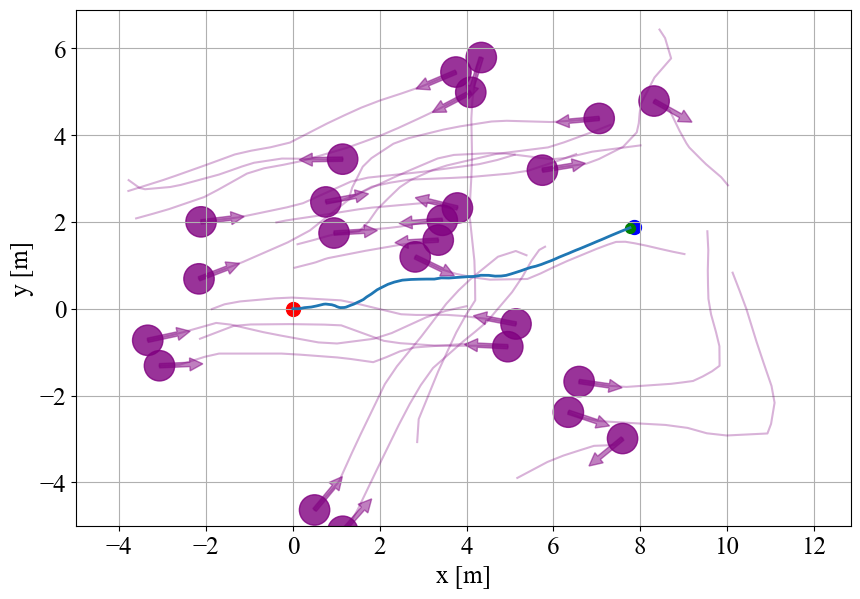

In [17]:
%matplotlib inline

# Prepare data for plotting
plot_obstacles = state_obs[:,:,:2,:].detach().cpu()
start_plot = state_ego[0, :2, 0].detach().cpu()
goal_plot = goal_pos.detach().cpu().squeeze()
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(0,0, c='r', s=100)

for j in range(plot_obstacles.shape[1]):
    ax.plot(plot_obstacles[0,j,0,:].detach().cpu().numpy(), plot_obstacles[0,j,1,:].detach().cpu().numpy(), 
            label="obstacle", lw=1.5, color='purple', alpha=0.3)
    circle = Circle((plot_obstacles[0,j,0,0], plot_obstacles[0,j,1,0]), 0.35, color='purple', fill=True, alpha=0.8)
    ax.add_patch(circle)

    xt = plot_obstacles[0,j,0,0]
    yt = plot_obstacles[0,j,1,0]
    xt_n = plot_obstacles[0,j,0,5]
    yt_n = plot_obstacles[0,j,1,5]
    norm = np.sqrt((xt_n-xt)**2 + (yt_n-yt)**2)
    ax.arrow(x=xt, y=yt, dx=(xt_n-xt)/norm, dy=(yt_n-yt)/norm, width=0.1, head_width=0.3, head_length=0.3, 
            length_includes_head=True, fc='purple', ec='purple', alpha=0.5)



ax.scatter(goal_plot.squeeze()[0].detach().cpu().numpy(), goal_plot.squeeze()[1].detach().cpu().numpy(), c='b', s=100)
ax.plot(state_hist[0,:].detach().cpu().numpy(), state_hist[1,:].detach().cpu().numpy(), color='C0', label='robot', lw=2)
ax.scatter(state_hist[0,-1].detach().cpu().numpy(), state_hist[1,-1].detach().cpu().numpy(), c='g', s=50)

plt.xlabel('x [m]', fontsize=18)
plt.ylabel('y [m]', fontsize=18)
ax.grid(True)
plt.xlim(min(0, goal_plot[0])-5, goal_plot[0]+5)
plt.ylim(min(0, goal_plot[1])-5, goal_plot[1]+5)
plt.gca().set_aspect('equal')
plt.tick_params(axis='both', labelsize=18)
Path("../../images").mkdir(parents=True, exist_ok=True)
plt.savefig(f'../../images/{SCENARIO_IDX}_{dataset_name}_uni.png', bbox_inches='tight', pad_inches=0.05)
plt.show()

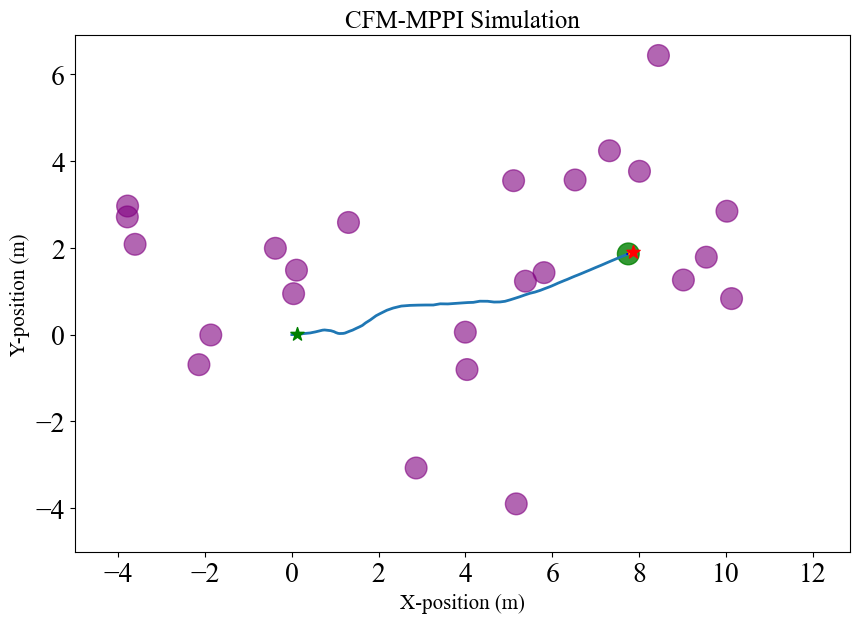

In [18]:
%matplotlib inline

# Prepare data for plotting
plot_obstacles = state_obs[:,:,:2,:].detach().cpu()
start_plot = state_ego[0, :2, 0].detach().cpu()
goal_plot = goal_pos.detach().cpu().squeeze()

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
plt.xlim(min(0, goal_plot[0])-5, max(0, goal_plot[0])+5)
plt.ylim(min(0, goal_plot[1])-5, max(0, goal_plot[1])+5)
ax.set_xlabel("X-position (m)")
ax.set_ylabel("Y-position (m)")
ax.set_title("CFM-MPPI Simulation")

# Static elements
ax.scatter(start_plot[0], start_plot[1], c='green', s=100, marker='*', label='Start', zorder=10)
ax.scatter(goal_plot[0], goal_plot[1], c='red', s=100, marker='*', label='Goal', zorder=10)

# Dynamic elements
ego_path_line, = ax.plot([], [], color='C0', lw=2, label='Ego Path')
ego_circle = Circle((0, 0), EGO_RADIUS/2, color='green', fill=True, alpha=0.8)
ax.add_patch(ego_circle)

num_obstacles = plot_obstacles.shape[1]
obstacle_circles = [
    Circle((0, 0), OBSTACLE_RADIUS/2, color='purple', fill=True, alpha=0.6) for _ in range(num_obstacles)
]
for circle in obstacle_circles:
    ax.add_patch(circle)

cfm_candidate_lines = [
    ax.plot([], [], color='green', linestyle=':', alpha=0.2, lw=1.0)[0]
    for _ in range(N_SAMPLES)
]
mppi_candidate_lines = [
    ax.plot([], [], color='blue', linestyle=':', alpha=0.1, lw=1.0)[0]
    for _ in range(N_SAMPLES*10)
]
optimal_mode_lines = [
    ax.plot([], [], color='orange', linestyle='--', alpha=0.7, lw=2.0)[0]
    for _ in range(10)
]
optimal_line, = ax.plot([], [], color='red', linestyle='--', label='Optimal Plan', lw=3)

def update(frame):
    # Update ego path
    x_data = state_hist[0, :frame + 1].numpy()
    y_data = state_hist[1, :frame + 1].numpy()
    ego_path_line.set_data(x_data, y_data)
    ego_circle.set_center((x_data[-1], y_data[-1]))

    # Update obstacles
    for j, obs_circle in enumerate(obstacle_circles):
        obs_x = plot_obstacles[0, j, 0, frame].numpy()
        obs_y = plot_obstacles[0, j, 1, frame].numpy()
        obs_circle.set_center((obs_x, obs_y))

    # Update CFM candidate trajectories
    if frame < len(cfm_candidates_list):
        cfm_candidates = cfm_candidates_list[frame]
        for i, cfm_candidate_line in enumerate(cfm_candidate_lines):
            candidate_x = cfm_candidates[i, 0, :]
            candidate_y = cfm_candidates[i, 1, :]
            cfm_candidate_line.set_data(candidate_x, candidate_y)

    # Update MPPI candidate trajectories
    if frame < len(mppi_candidates_list):
        mppi_candidates = mppi_candidates_list[frame]
        for i, mppi_candidate_line in enumerate(mppi_candidate_lines):
            candidate_x = mppi_candidates[i, 0, :]
            candidate_y = mppi_candidates[i, 1, :]
            mppi_candidate_line.set_data(candidate_x, candidate_y)

    # Update Optimal mode trajectories
    if frame < len(optimal_modes_list):
        optimal_modes = optimal_modes_list[frame]
        for i, mppi_candidate_line in enumerate(optimal_mode_lines):
            candidate_x = optimal_modes[i, 0, :]
            candidate_y = optimal_modes[i, 1, :]
            mppi_candidate_line.set_data(candidate_x, candidate_y)

    # Update optimal planned trajectory
    if frame < len(optimal_traj_list):
        optimal_state = optimal_traj_list[frame]
        optimal_x = optimal_state[0, :]
        optimal_y = optimal_state[1, :]
        optimal_line.set_data(optimal_x, optimal_y)

    return [ego_path_line, ego_circle, optimal_line] + obstacle_circles

ani = animation.FuncAnimation(fig, update, frames=HORIZON, interval=100, blit=True)


Path("../../videos").mkdir(parents=True, exist_ok=True)
ani.save(f"../../videos/{SCENARIO_IDX}_{dataset_name}_uni.mp4", writer="ffmpeg", fps=10)